In [5]:
import polars as pl
import numpy as np
import pandas as pd
import seaborn as sns




In [6]:
# Habilitar Cache 
# Quando se faz uma leitura de String  ela é mais custosa no uso de memória e de processamento que uma numérica
# Quando observa-se que numa coluna há valores diferentes para cada linha não há o que fazer
# Mas quando numa coluna encontramos valores repetitivos, pode-se otimizar usando:
# no polars: .cast(pl.Categorical)
# no Pandas: .astype('category')
# A linha de código a seguir faz com que o dicionário mapeie um número em relação a categoria e que ela seja de uso global,
# ou seja, todas as colunas categóricas usarão o mesmo mapeamento, e seja utilizado por qualquer outra tabela que seja lida no arquivo
pl.enable_string_cache()


In [9]:
df = pl.read_csv("03.BaseDPEvolucaoMensalCisp.csv", separator = ';', encoding = 'iso-8859-1')
df_dp = pl.read_csv('08.DP.csv', separator = ',', encoding = 'utf-8')

df = df.join(df_dp, left_on='cisp', right_on='codDP', how = 'left')
# Substitua 'common_column' pelo nome da coluna comum entre os dois DataFrames
df.glimpse()

Rows: 34848
Columns: 65
$ cisp                       <i64> 1, 4, 5, 6, 7, 9, 10, 12, 13, 14
$ mes                        <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ ano                        <i64> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003
$ mes_ano                    <str> '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01'
$ aisp                       <i64> 5, 5, 5, 1, 1, 2, 2, 19, 19, 23
$ risp                       <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ munic                      <str> 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro'
$ mcirc                      <i64> 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557
$ regiao                     <str> 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Ca

In [10]:
df = df.with_columns( 
    pl.col('munic').cast(pl.Categorical),
    pl.col('regiao').cast(pl.Categorical),
    pl.col('nome').cast(pl.Categorical)
)
    # se por acaso houvesse uma coluna com string que se desejasse converter em float, poderia-se usar: pl.col('coluna').cast(pl.Float64)

In [18]:
# Correlação entre colunas 1 e 2
coluna1 = 'roubo_veiculo'
coluna2 = 'recuperacao_veiculos'

corr = df.select(
    pl.corr(coluna1, coluna2)
).item()
display(corr)

0.8454989636146697

In [ ]:
# Analise por municipio por ano e por dP
df_municipio_agg = (
    df.group_by('munic')
    .agg ([pl.mean(coluna1).alias(f'media_{coluna1}'),
           pl.mean(coluna2).alias(f'media_{coluna2}')
    ])
)

df_municipio_agg.select(
    pl.corr(f'media_{coluna1}', f'media_{coluna2}')
)
# Neste caso buscamos verificar a correlação entre as médias das colunas de todos os municípios
# usando a media de roubos e a media de recuperacao de veiculos

media_roubo_veiculo
f64
0.974349


In [ ]:
# Por municipios por ano
df_municipio_ano_agg = (
    df.group_by(['munic', 'ano']).agg(
        pl.sum(coluna1).alias(f'total_{coluna1}'),
        pl.sum(coluna2).alias(f'total_{coluna2}')
        # aqui poderia se fazer pl.corr(coluna1, coluna2)
    )
)
df_municipio_ano_agg.select(
    pl.corr(f'total_{coluna1}', f'total_{coluna2}')
)
display(df_municipio_ano_agg)

munic,ano,total_roubo_veiculo,total_recuperacao_veiculos
cat,i64,i64,i64
"""Natividade;Varre-Sai""",2008,2,1
"""São José do Vale do Rio Preto""",2005,0,5
"""Trajano de Morais""",2014,1,4
"""Japeri""",2006,14,18
"""Armação dos Búzios""",2020,10,11
…,…,…,…
"""Valença""",2006,6,23
"""Piraí""",2016,8,18
"""Cabo Frio;Arraial do Cabo""",2008,71,120


In [17]:
# Por municipios por ano
df_municipio_ano_agg = (
    df.group_by(['munic', 'ano']).agg(
        pl.corr(coluna1, coluna2)
        .alias(f'correlacao_{coluna1}_{coluna2}')
    ).sort('ano')
)
df_municipio_ano_agg.filter(
    pl.col('munic') == 'Rio de Janeiro'
)
display(df_municipio_ano_agg)

munic,ano,correlacao_roubo_veiculo_recuperacao_veiculos
cat,i64,f64
"""Piraí;Pinheiral""",2003,0.351024
"""Duas Barras""",2003,-0.090909
"""Valença""",2003,-0.545777
"""Nova Iguaçu""",2003,0.37138
"""Araruama""",2003,0.288653
…,…,…
"""Sumidouro""",2024,NaN
"""Magé""",2024,0.501916
"""Piraí""",2024,-0.040032


Text(0.5, 1.0, 'Correlação (r: 0.85) entre roubo_veiculo e recuperacao_veiculos')

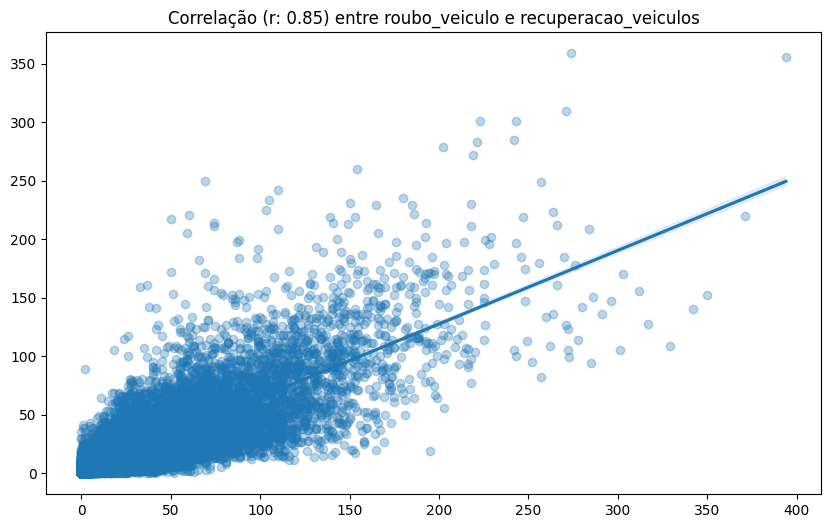

In [21]:
# Gráficos de dispersão e correlação
import matplotlib.pyplot as plt
plt.figure(figsize= (10, 6))
sns.regplot(
    data = df,
    x = coluna1,
    y = coluna2,
    scatter_kws = {'alpha': 0.3}
)
plt.title(f'Correlação (r: {corr:.2f}) entre {coluna1} e {coluna2}')